# Combined Transcriptomics Cleaning
Processes 2019_UGA, 2020_UGA, SDY2867, and 2024_UGA (challenge) with a shared pipeline including joint batch correction, then saves train and challenge as separate parquets.

In [1]:
!pip install pycombat
!pip install combat


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
sys.path.insert(0, '../..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from combat.pycombat import pycombat
from sklearn.decomposition import PCA

from data_cleaning.utils import peek

DATA_PATH = "../../data"
CLEAN_DATA_PATH = "../../cleaned_data"
MIN_PRESENT = 1  # drop any column with less than % non-NaN values

In [3]:
df_challenge = pd.read_csv(DATA_PATH + '/challenge_transcriptomics.tsv', sep='\t')
unique_genes_challenge = set(df_challenge['ensembl_gene_id'].unique())
print(f"Challenge genes: {len(unique_genes_challenge)}")

Challenge genes: 54902


In [4]:
df_2019_uga = pd.read_csv(DATA_PATH + '/train_transcriptomics_2019_UGA.tsv', sep='\t')
df_2020_uga = pd.read_csv(DATA_PATH + '/train_transcriptomics_2020_UGA.tsv', sep='\t')
df_sdy2867 = pd.read_csv(DATA_PATH + '/train_transcriptomics_SDY2867.tsv', sep='\t')

df_raw = pd.concat([df_2019_uga, df_2020_uga, df_sdy2867, df_challenge], axis=0).reset_index(drop=True)
print(f"Combined raw: {df_raw.shape}")
df_raw.head()

Combined raw: (60389504, 7)


,transcriptomics_id,participant_id,timepoint,ensembl_gene_id,raw_count,tpm_count,material
0,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000003,NaN,0.077926,Unknown
1,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000005,NaN,0.000000,Unknown
2,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000419,NaN,5.342548,Unknown
3,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000457,NaN,9.799336,Unknown
4,BS_RNA__2019_UGA.ID_208__2019_UGA_Standard_Flu...,2019_UGA.ID_208,0,ENSG00000000460,NaN,2.118530,Unknown


In [5]:
# Basic preprocessing, drop unused cols, and genes not in common with the challenge set
df = df_raw.drop(columns=['transcriptomics_id', 'raw_count', 'material'])
df = df[df['timepoint'].isin([
    0
    # 7  # too much missingness
])]
df = df[df['ensembl_gene_id'].isin(unique_genes_challenge)]
print(len(df))
df.head()

16440274


,participant_id,timepoint,ensembl_gene_id,tpm_count
0,2019_UGA.ID_208,0,ENSG00000000003,0.077926
1,2019_UGA.ID_208,0,ENSG00000000005,0.000000
2,2019_UGA.ID_208,0,ENSG00000000419,5.342548
3,2019_UGA.ID_208,0,ENSG00000000457,9.799336
4,2019_UGA.ID_208,0,ENSG00000000460,2.118530


In [6]:
df_pivot = df.pivot_table(
    index='participant_id',
    columns=['timepoint', 'ensembl_gene_id'],
    values='tpm_count'
)
df_pivot.columns = [f'TRAN_{gene}_d{int(tp)}' for tp, gene in df_pivot.columns]
df_pivot = df_pivot.reset_index()

In [7]:
peek(df_pivot)

,participant_id,TRAN_ENSG00000000003_d0,TRAN_ENSG00000000005_d0,TRAN_ENSG00000000419_d0,TRAN_ENSG00000000457_d0,TRAN_ENSG00000000460_d0,TRAN_ENSG00000000938_d0,TRAN_ENSG00000000971_d0,TRAN_ENSG00000001036_d0,TRAN_ENSG00000001084_d0,TRAN_ENSG00000001167_d0,TRAN_ENSG00000001460_d0,TRAN_ENSG00000001461_d0,TRAN_ENSG00000001497_d0,TRAN_ENSG00000001561_d0,TRAN_ENSG00000001617_d0,TRAN_ENSG00000001626_d0,TRAN_ENSG00000001629_d0,TRAN_ENSG00000001630_d0,TRAN_ENSG00000001631_d0
0,2019_UGA.ID_001,0.149866,0.0,8.066946,8.457258,3.973795,95.386306,0.034801,13.583601,7.965179,7.187047,1.590390,13.973659,9.685137,3.203689,0.000000,0.0,10.685926,3.141505,8.707056
1,2019_UGA.ID_005,0.119232,0.0,3.209018,7.973900,2.521538,83.430649,0.110751,10.308613,12.190398,9.965058,1.533703,16.946756,10.774215,6.274083,0.029305,0.0,16.372074,2.892793,11.885934
2,2019_UGA.ID_008,0.096349,0.0,5.277265,7.289030,1.913696,138.440845,0.143194,10.557651,14.385306,5.401848,1.982958,9.914634,6.998915,2.006857,0.000000,0.0,4.988143,2.244099,6.075266
3,2019_UGA.ID_011,0.044666,0.0,3.733021,8.731205,3.491700,150.812198,0.074682,11.532723,14.860079,11.703771,1.149111,10.513365,6.511664,10.136052,0.000000,0.0,15.577613,2.566189,12.220556
4,2019_UGA.ID_014,0.000000,0.0,5.207440,9.466478,2.931771,129.608966,0.128051,15.970298,13.050625,10.539603,1.994948,15.887030,8.589723,10.012239,0.112938,0.0,14.760842,3.121698,10.802686


In [8]:
gene_cols = [c for c in df_pivot.columns if c != 'participant_id']
present_frac = df_pivot[gene_cols].notna().mean()
sparse_cols = present_frac[present_frac < MIN_PRESENT].index.tolist()
df_pivot = df_pivot.drop(columns=sparse_cols)
print(f'Dropped {len(sparse_cols)} columns with <{MIN_PRESENT:.0%} present values.')
print(f'Shape after dropping: {df_pivot.shape}')

Dropped 24080 columns with <100% present values.
Shape after dropping: (435, 30823)


In [9]:
d0_genes = {c.replace('_d0', '') for c in df_pivot.columns if c.endswith('_d0')}
d7_genes = {c.replace('_d7', '') for c in df_pivot.columns if c.endswith('_d7')}
missing_d7 = d0_genes - d7_genes
print(f"d0 cols: {len(d0_genes)}, d7 cols: {len(d7_genes)}")
print(f"Genes with d0 but no d7: {len(missing_d7)}")

d0 cols: 30822, d7 cols: 0
Genes with d0 but no d7: 30822


## Batch correction

In [10]:
gene_cols = [c for c in df_pivot.columns if c != 'participant_id']

participants_2019_uga = set(df_2019_uga['participant_id'].unique())
participants_2020_uga = set(df_2020_uga['participant_id'].unique())
participants_sdy2867 = set(df_sdy2867['participant_id'].unique())
participants_challenge = set(df_challenge['participant_id'].unique())


def get_batch(pid):
    if pid in participants_2019_uga:
        return '2019_UGA'
    elif pid in participants_2020_uga:
        return '2020_UGA'
    elif pid in participants_sdy2867:
        return 'SDY2867'
    else:
        return '2024_UGA'


batch = df_pivot['participant_id'].map(get_batch).tolist()
print("Batch counts:", pd.Series(batch).value_counts().to_dict())

Batch counts: {'2019_UGA': 275, 'SDY2867': 72, '2020_UGA': 48, '2024_UGA': 40}


In [11]:
# pycombat expects genes x samples DataFrame in log scale
expr_df = pd.DataFrame(
    np.log1p(df_pivot[gene_cols].values).T,
    index=gene_cols,
    columns=df_pivot['participant_id']
)
corrected_df = pycombat(expr_df, batch)

# Put corrected log-scale values back
df_pivot[gene_cols] = corrected_df.values.T
print("Batch correction done. Shape:", df_pivot.shape)
peek(df_pivot)

Found 4 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\combat\pycombat.py:159: RuntimeWarning: divide by zero encountered in divide
  np.absolute(d_new-d_old)/d_old))  # maximum difference between new and old estimate


Adjusting the Data
Batch correction done. Shape: (435, 30823)


,participant_id,TRAN_ENSG00000000003_d0,TRAN_ENSG00000000005_d0,TRAN_ENSG00000000419_d0,TRAN_ENSG00000000457_d0,TRAN_ENSG00000000460_d0,TRAN_ENSG00000000938_d0,TRAN_ENSG00000000971_d0,TRAN_ENSG00000001036_d0,TRAN_ENSG00000001084_d0,TRAN_ENSG00000001167_d0,TRAN_ENSG00000001460_d0,TRAN_ENSG00000001461_d0,TRAN_ENSG00000001497_d0,TRAN_ENSG00000001561_d0,TRAN_ENSG00000001617_d0,TRAN_ENSG00000001626_d0,TRAN_ENSG00000001629_d0,TRAN_ENSG00000001630_d0,TRAN_ENSG00000001631_d0
0,2019_UGA.ID_001,0.217676,0.000681,2.700943,2.193857,1.538282,5.014220,0.374041,2.917761,2.332826,2.480567,0.880844,2.733046,2.578877,1.636570,0.016114,-0.000278,2.587809,1.585122,2.224601
1,2019_UGA.ID_005,0.178297,0.000681,2.142656,2.150939,1.248649,4.903687,0.453118,2.690169,2.665814,2.721275,0.863687,2.892106,2.664688,2.106086,0.069490,-0.000278,2.919791,1.529944,2.447571
2,2019_UGA.ID_008,0.148174,0.000681,2.433441,2.085995,1.089712,5.322429,0.485261,2.709662,2.798550,2.277917,0.990256,2.455363,2.322883,1.349678,0.016114,-0.000278,2.027971,1.367534,1.975684
3,2019_UGA.ID_011,0.077755,0.000681,2.228017,2.217217,1.452762,5.393376,0.416261,2.782141,2.824759,2.842540,0.736037,2.502264,2.267317,2.470727,0.016114,-0.000278,2.880595,1.451871,2.467749
4,2019_UGA.ID_014,0.014031,0.000681,2.425303,2.276805,1.341080,5.267817,0.470374,3.053391,2.720295,2.763352,0.993367,2.838654,2.483249,2.461154,0.213850,-0.000278,2.838290,1.580851,2.378457


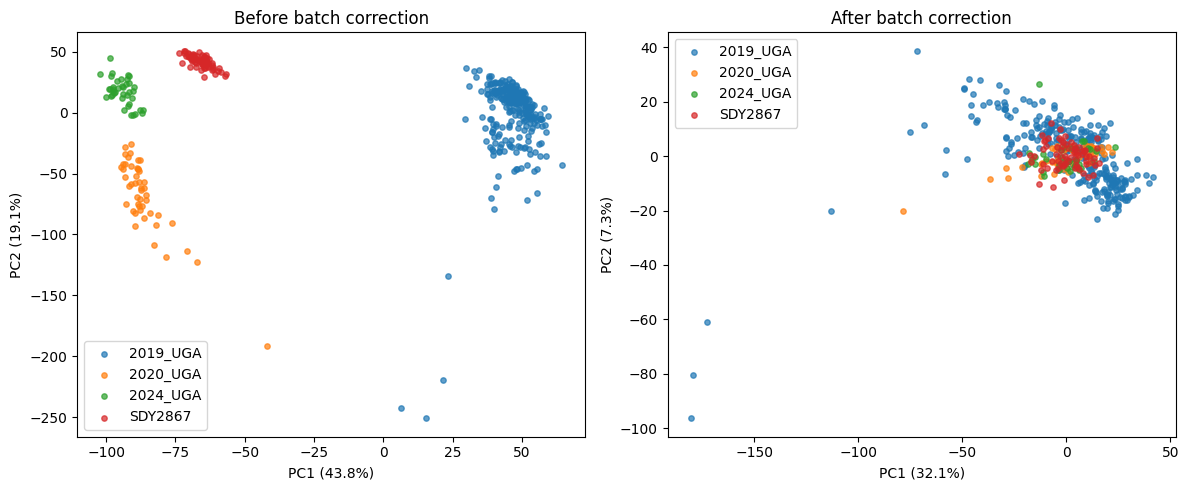

In [12]:
batch_series = pd.Series(batch)
unique_batches = batch_series.unique()
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(
        axes,
        [expr_df.T, corrected_df.T],
        ['Before batch correction', 'After batch correction']
):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(data.values)
    for i, b in enumerate(unique_batches):
        mask = (batch_series == b).values
        ax.scatter(coords[mask, 0], coords[mask, 1], label=b, alpha=0.7, s=15, color=colors[i])
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend()

plt.tight_layout()
plt.show()

70% variance explained by 28 PCs
75% variance explained by 48 PCs
80% variance explained by 84 PCs
90% variance explained by 202 PCs
95% variance explained by 290 PCs


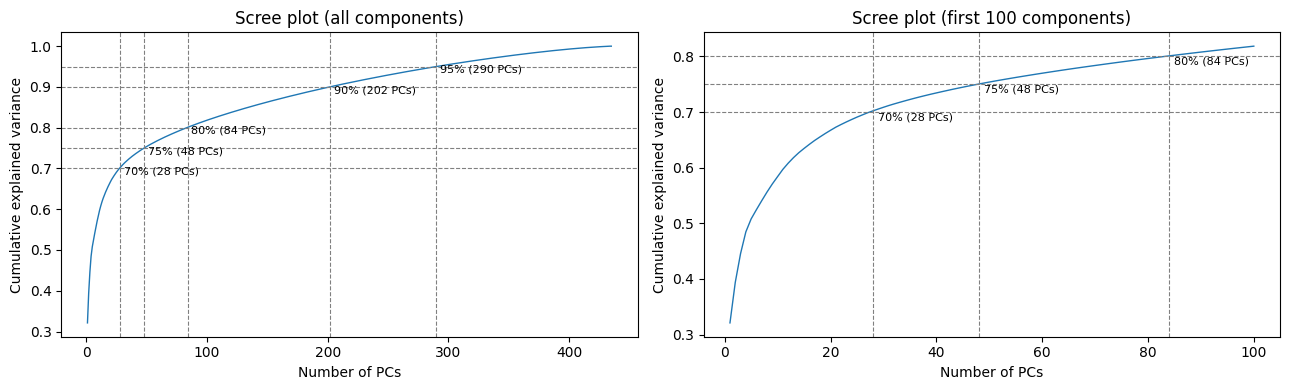

In [13]:
# EDA: scree plot to pick N_PCS
# svd_solver='full' is correct for wide data (n_samples=435 << n_features=30k)
pca_full = PCA(svd_solver='full', n_components=min(435, len(gene_cols)))
pca_full.fit(corrected_df.values.T)  # samples x genes

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.arange(1, len(cumvar) + 1)

thresholds = [0.70, 0.75, 0.80, 0.90, 0.95]
n_for_threshold = {t: np.searchsorted(cumvar, t) + 1 for t in thresholds}
for t, n in n_for_threshold.items():
    print(f"{t:.0%} variance explained by {n} PCs")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(n_components, cumvar, linewidth=1)
for t in thresholds:
    n = n_for_threshold[t]
    axes[0].axhline(t, color='grey', linestyle='--', linewidth=0.8)
    axes[0].axvline(n, color='grey', linestyle='--', linewidth=0.8)
    axes[0].text(n + 3, t - 0.015, f'{t:.0%} ({n} PCs)', fontsize=8)
axes[0].set_xlabel('Number of PCs')
axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title('Scree plot (all components)')

axes[1].plot(n_components[:100], cumvar[:100], linewidth=1)
for t in thresholds:
    n = n_for_threshold[t]
    if n <= 100:
        axes[1].axhline(t, color='grey', linestyle='--', linewidth=0.8)
        axes[1].axvline(n, color='grey', linestyle='--', linewidth=0.8)
        axes[1].text(n + 1, t - 0.015, f'{t:.0%} ({n} PCs)', fontsize=8)
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Scree plot (first 100 components)')

plt.tight_layout()
plt.show()

In [14]:
N_PCS = 290  # covers 95% variance; slice top X at training time

train_pids     = df_pivot[df_pivot['participant_id'].isin(
    participants_2019_uga | participants_2020_uga | participants_sdy2867
)]['participant_id'].values
challenge_pids = df_pivot[df_pivot['participant_id'].isin(
    participants_challenge
)]['participant_id'].values

# Fit on training data only, transform challenge into the same space
train_corrected     = corrected_df[train_pids].T      # 395 x genes
challenge_corrected = corrected_df[challenge_pids].T  # 40  x genes

# svd_solver='full': LAPACK thin SVD, correct for wide data (395 samples << 30k genes)
# randomized only helps when n_components << n_samples; 290/395=73% is too high to benefit
pca_final = PCA(n_components=N_PCS, svd_solver='full')
train_pcs     = pca_final.fit_transform(train_corrected)
challenge_pcs = pca_final.transform(challenge_corrected)

pc_cols = [f'TRAN_PC{i+1}' for i in range(N_PCS)]

df_train_pca = pd.DataFrame(train_pcs, columns=pc_cols)
df_train_pca.insert(0, 'participant_id', train_pids)

df_challenge_pca = pd.DataFrame(challenge_pcs, columns=pc_cols)
df_challenge_pca.insert(0, 'participant_id', challenge_pids)

print(f"Train PCA shape:     {df_train_pca.shape}")
print(f"Challenge PCA shape: {df_challenge_pca.shape}")
print(f"Variance explained by {N_PCS} PCs: {pca_final.explained_variance_ratio_.sum():.1%}")

Train PCA shape:     (395, 291)
Challenge PCA shape: (40, 291)
Variance explained by 290 PCs: 96.3%


In [15]:
os.makedirs(CLEAN_DATA_PATH, exist_ok=True)

df_train_pca.to_csv(CLEAN_DATA_PATH + '/transcriptomics_train_pca.csv', index=False)
df_challenge_pca.to_csv(CLEAN_DATA_PATH + '/transcriptomics_challenge_pca.csv', index=False)

print(f"Saved train PCA:     {df_train_pca.shape}")
print(f"Saved challenge PCA: {df_challenge_pca.shape}")

Saved train PCA:     (395, 291)
Saved challenge PCA: (40, 291)
